In [1]:
import pickle
import pandas as pd
import numpy as np
import operator
from numba import njit

In [2]:
ot = pd.read_pickle("pickles/sept.pickle")
nt = pd.read_pickle("pickles/tisch.pickle")
bible = pd.concat([ot, nt], axis=0)
strongs = pd.read_pickle("pickles/strongs.pickle")

In [3]:
with open('references-naive.pickle', 'rb') as f:
    found = pickle.load(f)

found = sorted(found, key=operator.itemgetter(0))

# quote start, quote end, source start, source end
found = [((nloc, nloc+nlen), (oloc, oloc+olen)) for nloc, nlen, oloc, olen in found]

In [4]:
@njit
def locs_overlap(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return s1 <= s2 <= e1 or s2 <= s1 <= e2


@njit
def refs_overlap(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return locs_overlap(nloc1, nloc2) and locs_overlap(oloc1, oloc2)


@njit
def merge_locs(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return min(s1, s2), max(e1, e2)


@njit
def merge_refs(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return merge_locs(nloc1, nloc2), merge_locs(oloc1, oloc2)


@njit
def mergify(found):
    merged = []
    deleted = [False] * len(found)
    for ridx1, ref1 in enumerate(found):
        if deleted[ridx1]: continue
        for ridx2 in range(ridx1+1, len(found)):
            ref2 = found[ridx2]
            if refs_overlap(ref1, ref2):
                if deleted[ridx2]: raise Exception
                merged.append(merge_refs(ref1, ref2))
                deleted[ridx2] = True
    return merged

In [5]:
merged = mergify(found)
len(merged)

1484

In [6]:
merged = mergify(found)
len(merged)

1484

In [7]:
references = pd.DataFrame(columns=['nstart', 'nlen', 'nend', 'ostart', 'olen', 'oend'], dtype=int)
for (nstart, nend), (ostart, oend) in merged:
    references.loc[len(references)] = [nstart, nend-nstart, nend, ostart, oend-ostart, oend]

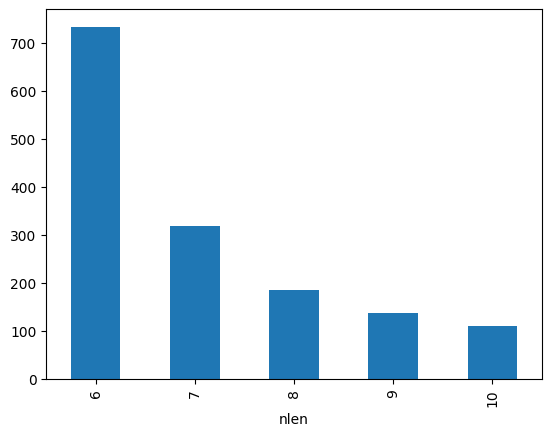

In [8]:
references['nlen'].value_counts().plot.bar();

In [9]:
bible.iloc[references[references.eval('nlen - olen') != 0]['ostart']][['book', 'chapter', 'verse']]

,book,chapter,verse
106185,5,6,5
106186,5,6,5
106188,5,6,5
106189,5,6,5
104782,5,4,29
109429,5,11,13
118288,5,26,16
121317,5,30,2
137037,6,22,5
137039,6,22,5


In [10]:
bible.iloc[references[references.eval('nlen - olen') != 0]['nstart']][['book', 'chapter', 'verse']]

,book,chapter,verse
26436,41,12,30
26436,41,12,30
26436,41,12,30
26436,41,12,30
26438,41,12,30
26438,41,12,30
26438,41,12,30
26438,41,12,30
26442,41,12,30
26442,41,12,30


In [ ]:
bible_books = [
    "Genesis",
    "Exodus",
    "Leviticus",
    "Numbers",
    "Deuteronomy",
    "Joshua",
    "Judges",
    "Ruth",
    "1 Samuel",
    "2 Samuel",
    "1 Kings",
    "2 Kings",
    "1 Chronicles",
    "2 Chronicles",
    "Ezra",
    "Nehemiah",
    "Esther",
    "Job",
    "Psalms",
    "Proverbs",
    "Ecclesiastes",
    "Song of Solomon",
    "Isaiah",
    "Jeremiah",
    "Lamentations",
    "Ezekiel",
    "Daniel",
    "Hosea",
    "Joel",
    "Amos",
    "Obadiah",
    "Jonah",
    "Micah",
    "Nahum",
    "Habakkuk",
    "Zephaniah",
    "Haggai",
    "Zechariah",
    "Malachi",
    "Matthew",
    "Mark",
    "Luke",
    "John",
    "Acts",
    "Romans",
    "1 Corinthians",
    "2 Corinthians",
    "Galatians",
    "Ephesians",
    "Philippians",
    "Colossians",
    "1 Thessalonians",
    "2 Thessalonians",
    "1 Timothy",
    "2 Timothy",
    "Titus",
    "Philemon",
    "Hebrews",
    "James",
    "1 Peter",
    "2 Peter",
    "1 John",
    "2 John",
    "3 John",
    "Jude",
    "Revelation",
]
bible_books = pd.Series(bible_books)

In [12]:
bible_books[:3]

0      Genesis
1       Exodus
2    Leviticus
dtype: object

In [13]:
bible_tuple = bible[["verse","chapter","book"]]
verse_dict = pd.Series(zip(bible_books.loc[bible_tuple['book']-1], bible_tuple['chapter'], bible_tuple['verse']))

In [14]:
references['nstart']

0       475406
1       475750
2       475750
3       475750
4       475750
         ...  
1479    612866
1480    612866
1481    612901
1482    612901
1483    612901
Name: nstart, Length: 1484, dtype: int64

In [15]:
verse_dict.iloc[references['nend']].index.duplicated().any()


True

In [16]:
references2 = pd.DataFrame(index = references.index)
references2['n_start'] = verse_dict.iloc[references['nstart']].reset_index(drop=True)
references2['n_end'] = verse_dict.iloc[references['nend']].reset_index(drop=True)
references2['o_start'] = verse_dict.iloc[references['ostart']].reset_index(drop=True)
references2['o_end'] = verse_dict.iloc[references['oend']].reset_index(drop=True)

In [17]:
references2

,n_start,n_end,o_start,o_end
0,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Genesis, 25, 19)","(Genesis, 25, 20)"
1,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 16, 11)","(Genesis, 16, 11)"
2,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 17, 19)","(Genesis, 17, 19)"
3,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 37)","(Genesis, 19, 37)"
4,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 38)","(Genesis, 19, 38)"
...,...,...,...,...
1479,"(Revelation, 22, 18)","(Revelation, 22, 19)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)"
1480,"(Revelation, 22, 18)","(Revelation, 22, 19)","(Jeremiah, 25, 13)","(Jeremiah, 25, 15)"
1481,"(Revelation, 22, 19)","(Revelation, 22, 20)","(Deuteronomy, 28, 58)","(Deuteronomy, 28, 58)"
1482,"(Revelation, 22, 19)","(Revelation, 22, 20)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)"


In [18]:
import plotly.express as px

In [24]:
(references2['n_start']).str[0]

0          Matthew
1          Matthew
2          Matthew
3          Matthew
4          Matthew
           ...    
1479    Revelation
1480    Revelation
1481    Revelation
1482    Revelation
1483    Revelation
Name: n_start, Length: 1484, dtype: object

In [26]:
book_authors = {
    "Genesis": "Moses",
    "Exodus": "Moses",
    "Leviticus": "Moses",
    "Numbers": "Moses",
    "Deuteronomy": "Moses",
    "Joshua": "Joshua",
    "Judges": "Samuel; Nathan; Gad",
    "Ruth": "Samuel",
    "1 Samuel": "Samuel; Nathan; Gad",
    "2 Samuel": "Gad; Nathan",
    "1 Kings": "Jeremiah",
    "2 Kings": "Jeremiah",
    "1 Chronicles": "Ezra",
    "2 Chronicles": "Ezra",
    "Ezra": "Ezra",
    "Nehemiah": "Nehemiah",
    "Esther": "Mordecai",
    "Job": "Unknown",
    "Psalms": "David and others",
    "Proverbs": "Solomon; Agur; Lemuel",
    "Ecclesiastes": "Solomon",
    "Song of Songs": "Solomon",
    "Isaiah": "Isaiah",
    "Jeremiah": "Jeremiah",
    "Lamentations": "Jeremiah",
    "Ezekiel": "Ezekiel",
    "Daniel": "Daniel",
    "Hosea": "Hosea",
    "Joel": "Joel",
    "Amos": "Amos",
    "Obadiah": "Obadiah",
    "Jonah": "Jonah",
    "Micah": "Micah",
    "Nahum": "Nahum",
    "Habakkuk": "Habakkuk",
    "Zephaniah": "Zephaniah",
    "Haggai": "Haggai",
    "Zechariah": "Zechariah",
    "Malachi": "Malachi",
    "Matthew": "Matthew",
    "Mark": "Mark",
    "Luke": "Luke",
    "John": "John",
    "Acts": "Luke",
    "Romans": "Paul",
    "1 Corinthians": "Paul",
    "2 Corinthians": "Paul",
    "Galatians": "Paul",
    "Ephesians": "Paul",
    "Philippians": "Paul",
    "Colossians": "Paul",
    "1 Thessalonians": "Paul",
    "2 Thessalonians": "Paul",
    "1 Timothy": "Paul",
    "2 Timothy": "Paul",
    "Titus": "Paul",
    "Philemon": "Paul",
    "Hebrews": "Unknown",
    "James": "James",
    "1 Peter": "Peter",
    "2 Peter": "Peter",
    "1 John": "John",
    "2 John": "John",
    "3 John": "John",
    "Jude": "Jude",
    "Revelation": "John"
}


In [31]:
px.histogram(
    x = references2['n_start'].str[0],
    labels={'x': 'Book of the Bible'}
)

In [36]:
px.histogram(
    x = references2['n_start'].str[0].map(book_authors),
    labels = {'x': 'Authors'}
)

In [37]:
references2['n_start']

0            (Matthew, 1, 1)
1           (Matthew, 1, 21)
2           (Matthew, 1, 21)
3           (Matthew, 1, 21)
4           (Matthew, 1, 21)
                ...         
1479    (Revelation, 22, 18)
1480    (Revelation, 22, 18)
1481    (Revelation, 22, 19)
1482    (Revelation, 22, 19)
1483    (Revelation, 22, 19)
Name: n_start, Length: 1484, dtype: object

In [38]:
references2.groupby('n_start')